In [35]:
%%HTML
<style>
    body {
        --vscode-font-family: "ComicSansMS"
    }
</style>

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

In [37]:
## Design requirements
PSRR_target_dB = -40  # Target PSRR in dB
f_bw = 100e3  # Desired bandwidth in Hz
PM_target = 60  # Target phase margin in degrees
I_load = 10e-3  # Load current in A
I_res_div = 5e-6  # Resistor divider current in A
V_out = 1.2  # Output voltage in V
V_ctrl = 1.25  # Control voltage in V
C_out = 100e-12  # Output capacitance in F

In [38]:
from LDO_functions import estimate_ldo_power_and_pass_params as ldo_arch1
from LDO_functions_Arch_2 import estimate_ldo_power_and_pass_params as ldo_arch2


In [39]:

## csv files
csv_file_nmos_sf = "sf_nmos_char_vg_1_3.csv"
csv_file_pmos_ldo_pass = "ldo_pmos_kgm_char_Msweep_10mA.csv"

## kgm targets
kgm1_target_arch1 = 25
kgm2_target_arch1 = 18
kgm1_target_arch2 = 25
kgm2_target_arch2 = 4

## Architecture 1 I_total estimation
result_arch1 = ldo_arch1(
    PSRR_target_dB=PSRR_target_dB,
    f_bw=f_bw,
    PM_target=PM_target,
    I_load=I_load,
    I_res_div=I_res_div,
    V_out=V_out,
    V_ctrl=V_ctrl,
    C_out=C_out,
    csv_file_nmos=csv_file_nmos_sf,
    csv_file_pmos=csv_file_pmos_ldo_pass,
    kgm_target=kgm2_target_arch1
)

print("Architecture 1 Results:")
print("I_total:", result_arch1['I_total'])
print("I_req1:", result_arch1['I_req1'])
print("I_req2:", result_arch1['I_req2'])
print("GBW_stage1:", result_arch1['GBW_stage1'])
print("GBW_stage2:", result_arch1['GBW_stage2'])

Resistor Divider Resistance (R_res_div) for 1% current overhead at I_max: 240000.00 Ohms
Total current through the PMOS pass transistor (I_total): 10.01 mA
Gate-Drain Capacitance (Cgd) at I_total 10.01 mA: 0.386 pF
Gate-Source Capacitance (Cgs) at I_total 10.01 mA: 0.949 pF
Effective Load Resistance (R_L_eff) considering Rds: 296.55 Ohms
Effective Load Capacitance at I_min: 100.402 pF
Load Resistance (R_L) required for bandwidth target 100000.0 Hz: 15851.82 Ohms
Using Resistor Divider Resistance (R_res_div): 240000.00 Ohms
Av_pass at I_total 10.01 mA: 25.10 V/V
Stage 2 required current (I_req_stage2): 0.1334 mA
Stage 2 input capacitance (C_in_stage2): 0.09 pF
Stage 1 required current (I_req_stage1): 0.0029 mA
Total required current (I_req_total): 0.1363 mA
Architecture 1 Results:
I_total: 0.00013634000336900764
I_req1: 2.913343038142229e-06
I_req2: 0.00013342666033086542
GBW_stage1: 92376043.0703401
GBW_stage2: 34641016.15137754


In [40]:
## csv files
csv_file_pmos_ldo_pass = "ldo_pmos_kgm_char_Msweep_10mA.csv"
csv_file_pmos_stage2 = "cs_amp_pmos_master.csv"


## kgm targets
kgm1_target_arch2 = 25
kgm2_target_arch2 = 4

result_arch2 = ldo_arch2(
    PSRR_target_dB, f_bw, PM_target, I_load, I_res_div, V_out, V_ctrl, C_out,
    csv_file_pmos_stage2, csv_file_pmos_ldo_pass,  kgm_target=kgm1_target_arch2
)

print("Architecture 2 Results:")
print("I_total:", result_arch2['I_total'])
print("I_req1:", result_arch2['I_req1'])
print("I_req2:", result_arch2['I_req2'])
print("GBW_stage1:", result_arch2['GBW_stage1'])
print("GBW_stage2:", result_arch2['GBW_stage2'])

Resistor Divider Resistance (R_res_div) for 1% current overhead at I_max: 240000.00 Ohms
Total current through the PMOS pass transistor (I_total): 10.01 mA
Gate-Drain Capacitance (Cgd) at I_total 10.01 mA: 0.386 pF
Gate-Source Capacitance (Cgs) at I_total 10.01 mA: 0.949 pF
Effective Load Resistance (R_L_eff) considering Rds: 296.55 Ohms
Effective Load Capacitance at I_min: 100.402 pF
Load Resistance (R_L) required for bandwidth target 100000.0 Hz: 15851.82 Ohms
Using Resistor Divider Resistance (R_res_div): 240000.00 Ohms
Av_pass at I_total 10.01 mA: 25.10 V/V
Architecture 2 Results:
I_total: 0.0030022007935494427
I_req1: 1.0093610497116948e-07
I_req2: 0.0030020998574444716
GBW_stage1: 883744.4828490113
GBW_stage2: 2596280662.4078426


In [41]:
## Comparison between two architectures
print(f"Architecture 1 Total Current (I_total): {result_arch1['I_total']*1e3:.2f} mA")
print(f"Architecture 2 Total Current (I_total): {result_arch2['I_total']*1e3:.2f} mA")

Architecture 1 Total Current (I_total): 0.14 mA
Architecture 2 Total Current (I_total): 3.00 mA


Resistor Divider Resistance (R_res_div) for 1% current overhead at I_max: 240000.00 Ohms
Total current through the PMOS pass transistor (I_total): 10.01 mA
Gate-Drain Capacitance (Cgd) at I_total 10.01 mA: 0.386 pF
Gate-Source Capacitance (Cgs) at I_total 10.01 mA: 0.949 pF
Effective Load Resistance (R_L_eff) considering Rds: 296.55 Ohms
Effective Load Capacitance at I_min: 100.402 pF
Load Resistance (R_L) required for bandwidth target 100000.0 Hz: 15851.82 Ohms
Using Resistor Divider Resistance (R_res_div): 240000.00 Ohms
Av_pass at I_total 10.01 mA: 25.10 V/V
Stage 2 required current (I_req_stage2): 1.3343 mA
Stage 2 input capacitance (C_in_stage2): 0.90 pF
Stage 1 required current (I_req_stage1): 2.9133 mA
Total required current (I_req_total): 4.2476 mA
Resistor Divider Resistance (R_res_div) for 1% current overhead at I_max: 240000.00 Ohms
Total current through the PMOS pass transistor (I_total): 10.01 mA
Gate-Drain Capacitance (Cgd) at I_total 10.01 mA: 0.386 pF
Gate-Source Capaci

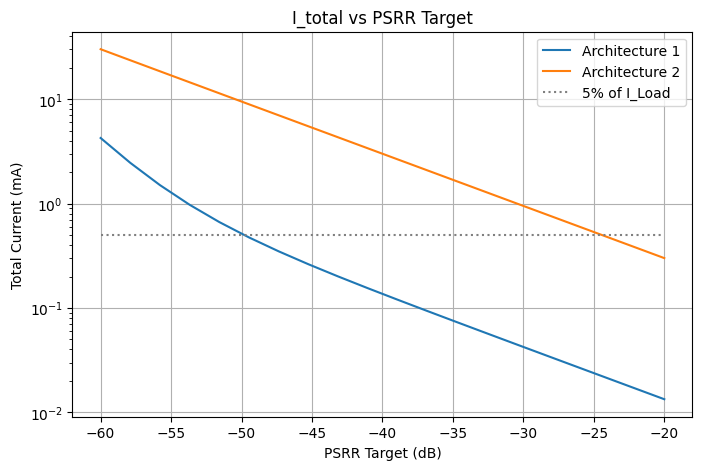

In [42]:

psrr_values = np.linspace(-60, -20, 20)

##
kgm1_target_arch1 = 25
kgm2_target_arch1 = 18

kgm1_target_arch2 = 25
kgm2_target_arch2 = 4

# Store I_total for each architecture as a function of PSRR
I_total_arch1 = []
I_total_arch2 = []

for psrr in psrr_values:
    # Architecture 1
    res1 = ldo_arch1(
        PSRR_target_dB=psrr,
        f_bw=f_bw,
        PM_target=PM_target,
        I_load=I_load,
        I_res_div=I_res_div,
        V_out=V_out,
        V_ctrl=V_ctrl,
        C_out=C_out,
        csv_file_nmos=csv_file_nmos_sf,
        csv_file_pmos=csv_file_pmos_ldo_pass,
        kgm_target=kgm2_target_arch1
    )
    I_total_arch1.append(res1['I_total'])

    # Architecture 2
    res2 = ldo_arch2(
        PSRR_target_dB=psrr,
        f_bw=f_bw,
        PM_target=PM_target,
        I_load=I_load,
        I_res_div=I_res_div,
        V_out=V_out,
        V_ctrl=V_ctrl,
        C_out=C_out,
        csv_file_pmos_stage2=csv_file_pmos_stage2,
        csv_file_pass_pmos=csv_file_pmos_ldo_pass,
        kgm_target=kgm1_target_arch2
    )
    I_total_arch2.append(res2['I_total'])

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(psrr_values, np.array(I_total_arch1)*1e3, label='Architecture 1')
plt.plot(psrr_values, np.array(I_total_arch2)*1e3, label='Architecture 2')
plt.xlabel('PSRR Target (dB)')
plt.ylabel('Total Current (mA)')
plt.hlines(
    y=I_load*1e3*0.05,
    xmin=psrr_values.min(),
    xmax=psrr_values.max(),
    colors='gray',
    linestyles='dotted',
    label='5% of I_Load'
)
plt.yscale('log')
plt.title('I_total vs PSRR Target')
plt.legend()
plt.grid(True)
plt.show()

Resistor Divider Resistance (R_res_div) for 1% current overhead at I_max: 240000.00 Ohms
Total current through the PMOS pass transistor (I_total): 10.01 mA
Gate-Drain Capacitance (Cgd) at I_total 10.01 mA: 0.386 pF
Gate-Source Capacitance (Cgs) at I_total 10.01 mA: 0.949 pF
Effective Load Resistance (R_L_eff) considering Rds: 296.55 Ohms
Effective Load Capacitance at I_min: 100.402 pF
Load Resistance (R_L) required for bandwidth target 10000.0 Hz: 158518.17 Ohms
Using Resistor Divider Resistance (R_res_div): 240000.00 Ohms
Av_pass at I_total 10.01 mA: 25.10 V/V
Stage 2 required current (I_req_stage2): 0.0133 mA
Stage 2 input capacitance (C_in_stage2): 0.01 pF
Stage 1 required current (I_req_stage1): 0.0000 mA
Total required current (I_req_total): 0.0134 mA
Resistor Divider Resistance (R_res_div) for 1% current overhead at I_max: 240000.00 Ohms
Total current through the PMOS pass transistor (I_total): 10.01 mA
Gate-Drain Capacitance (Cgd) at I_total 10.01 mA: 0.386 pF
Gate-Source Capaci

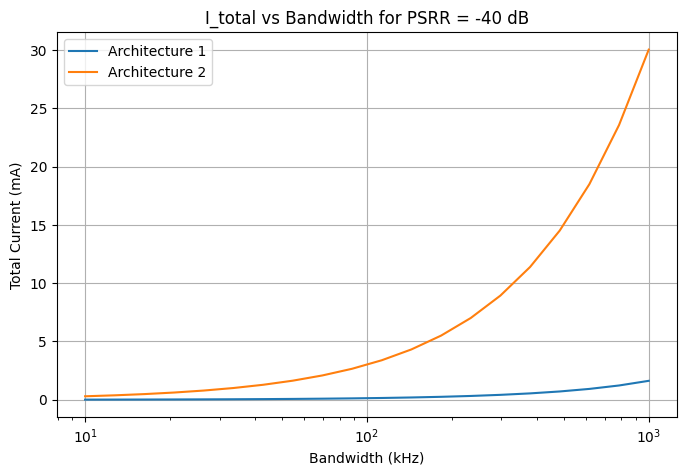

In [43]:
# Define a range of bandwidth values (e.g., from 10 kHz to 1 MHz)
bw_values = np.logspace(np.log10(10e3), np.log10(1e6), 20)

I_total_arch1_bw = []
I_total_arch2_bw = []

for bw in bw_values:
    # Architecture 1
    res1_bw = ldo_arch1(
        PSRR_target_dB=-40,
        f_bw=bw,
        PM_target=PM_target,
        I_load=I_load,
        I_res_div=I_res_div,
        V_out=V_out,
        V_ctrl=V_ctrl,
        C_out=C_out,
        csv_file_nmos=csv_file_nmos_sf,
        csv_file_pmos=csv_file_pmos_ldo_pass,
        kgm_target=kgm2_target_arch1
    )
    I_total_arch1_bw.append(res1_bw['I_total'])

    # Architecture 2
    res2_bw = ldo_arch2(
        PSRR_target_dB=-40,
        f_bw=bw,
        PM_target=PM_target,
        I_load=I_load,
        I_res_div=I_res_div,
        V_out=V_out,
        V_ctrl=V_ctrl,
        C_out=C_out,
        csv_file_pmos_stage2=csv_file_pmos_stage2,
        csv_file_pass_pmos=csv_file_pmos_ldo_pass,
        kgm_target=kgm1_target_arch2
    )
    I_total_arch2_bw.append(res2_bw['I_total'])

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(bw_values / 1e3, np.array(I_total_arch1_bw) * 1e3, label='Architecture 1')
plt.plot(bw_values / 1e3, np.array(I_total_arch2_bw) * 1e3, label='Architecture 2')
plt.xscale('log')
plt.xlabel('Bandwidth (kHz)')
plt.ylabel('Total Current (mA)')
plt.title('I_total vs Bandwidth for PSRR = -40 dB')
plt.legend()
plt.grid(True)
plt.show()